In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [25]:
df = pd.read_csv("finalsortedrows.csv")  # replace with your file path

df.tail(3)

,carbohydrates_(g),cholesterol_(mg),energy_(kcal),fat_(g),fiber_(g),minerals_(mg),proteins_(g),salt/sodium_(mg),saturated-fat_(g),vitamins_(mg),nova_group
149997,27.0,5.0,375.0,15.0,2.2,300.0,7.0,900.0,6.0,1.5,4.0
149998,26.0,0.0,150.0,0.5,1.0,10.0,3.0,5.0,0.1,0.1,3.0
149999,27.0,5.0,375.0,15.0,2.2,300.0,7.0,900.0,6.0,1.5,4.0


In [27]:
df['energy_(kcal)'] = df['energy_(kcal)']/4.186

In [29]:
df.sample(2)

,carbohydrates_(g),cholesterol_(mg),energy_(kcal),fat_(g),fiber_(g),minerals_(mg),proteins_(g),salt/sodium_(mg),saturated-fat_(g),vitamins_(mg),nova_group
83390,0.000000,0.0,0.00000,0.000000,0.0,0.000000,0.0,3.689500,0.0,0.184,3.0
33015,66.666667,0.0,416.38796,16.666667,0.0,0.129024,0.0,0.416667,0.0,0.021,4.0


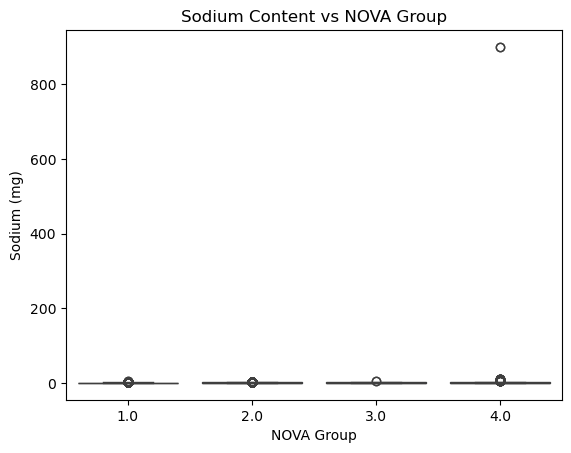

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Example for Sodium
sns.boxplot(x='nova_group', y='salt/sodium_(mg)', data=df)
plt.title('Sodium Content vs NOVA Group')
plt.xlabel('NOVA Group')
plt.ylabel('Sodium (mg)')
plt.show()

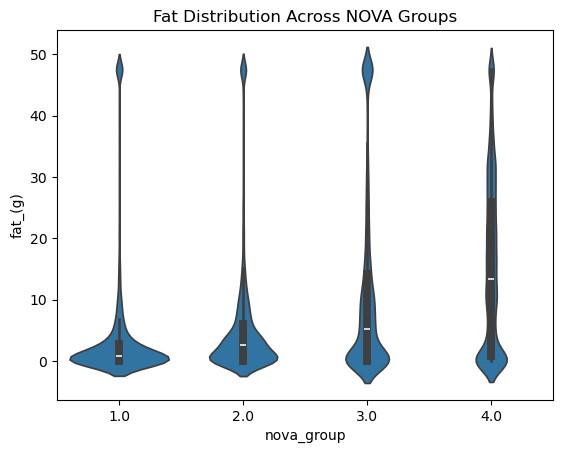

In [33]:
sns.violinplot(x='nova_group', y='fat_(g)', data=df)
plt.title('Fat Distribution Across NOVA Groups')
plt.savefig("violin.jpg", format='jpg', dpi=300)
plt.show()


Let’s say you’re looking at fat content across NOVA groups.

📌 Example Observations:
NOVA 1: Narrow and short violin → low and consistent fat values.

NOVA 4: Tall and wide violin with fat tail → wide range of fat content, and high values frequent.

NOVA 2 and 3: Moderate spread → some variation in fat content.

💡 What This Tells You:
"Foods in NOVA group 4 tend to have much higher and more variable fat content than minimally processed foods in group 1."

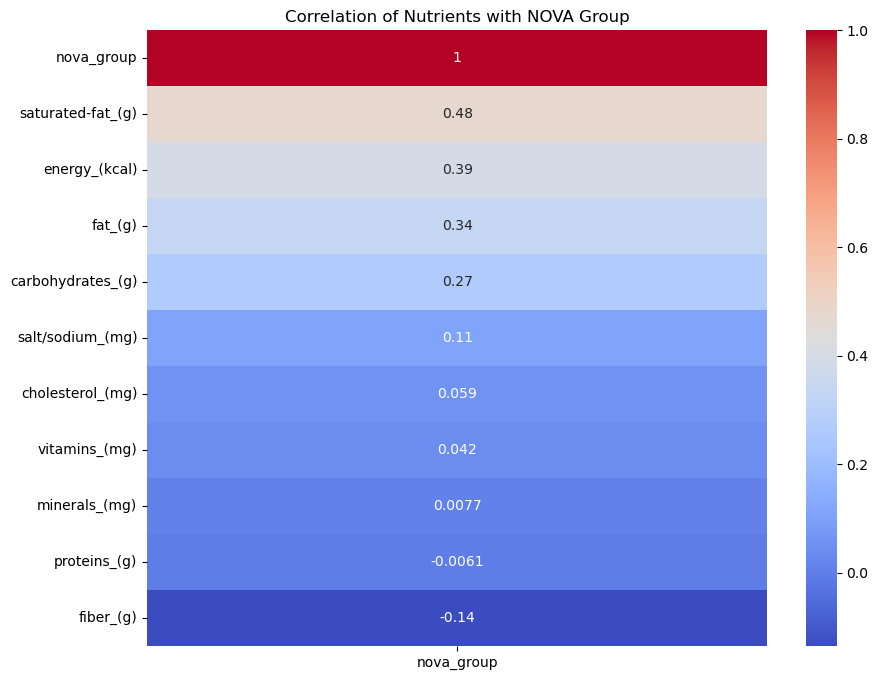

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr[['nova_group']].sort_values(by='nova_group', ascending=False), annot=True, cmap='coolwarm')
plt.title('Correlation of Nutrients with NOVA Group')
plt.savefig("Correlation.jpg", format='jpg', dpi=300)
plt.show()


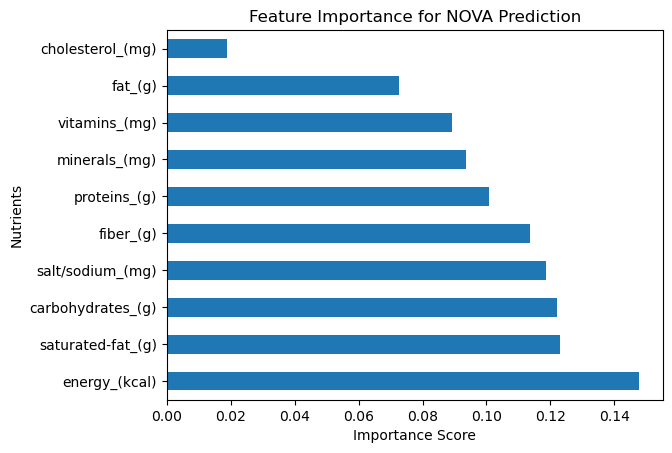

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
X=df.drop('nova_group', axis=1)
y =df['nova_group']

model = RandomForestClassifier()
model.fit(X, y)
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title('Feature Importance for NOVA Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Nutrients')
plt.savefig("feature_importance.jpg", format='jpg', dpi=300)
plt.show()

In [39]:
df.columns

Index(['carbohydrates_(g)', 'cholesterol_(mg)', 'energy_(kcal)', 'fat_(g)',
       'fiber_(g)', 'minerals_(mg)', 'proteins_(g)', 'salt/sodium_(mg)',
       'saturated-fat_(g)', 'vitamins_(mg)', 'nova_group'],
      dtype='object')

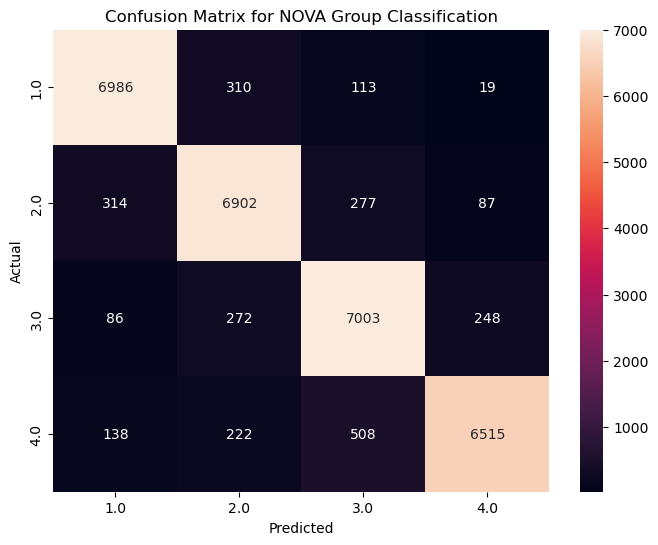

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Assuming your DataFrame is called 'df'
features = ['carbohydrates_(g)', 'cholesterol_(mg)', 'energy_(kcal)', 'fat_(g)',
            'fiber_(g)', 'minerals_(mg)', 'proteins_(g)', 'salt/sodium_(mg)',
            'saturated-fat_(g)', 'vitamins_(mg)']
target = 'nova_group'

# Split into X and y
X = df[features]
y = df[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train classifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
labels = sorted(y.unique())  # assuming nova_group contains 1,2,3,4 etc.

# Plot using seaborn
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for NOVA Group Classification')
plt.savefig("Confustion_Matrix.jpg", format='jpg', dpi=300)
plt.show()


In [12]:
model.predict(X)

array([1., 2., 1., ..., 4., 3., 4.])

In [13]:
model.score(X,y)*100

97.69733333333333

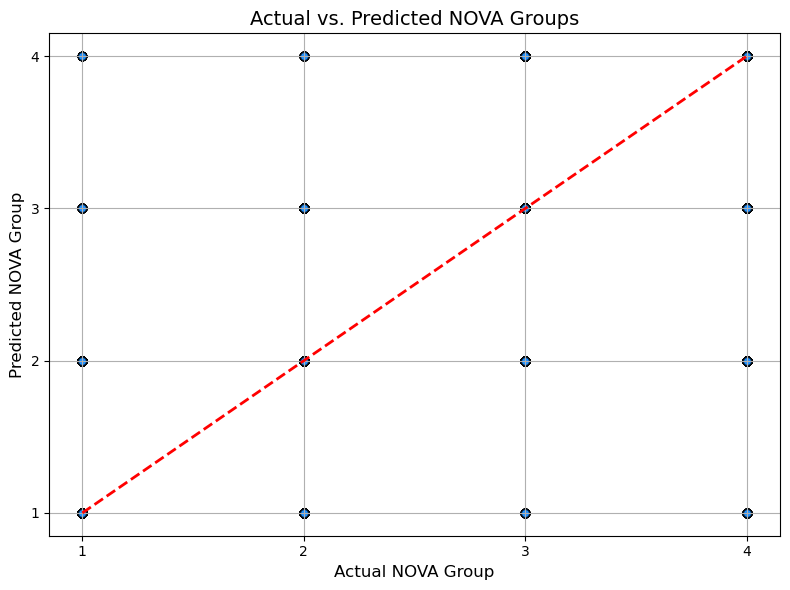

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# These must be integers or discrete labels like 1, 2, 3, 4
# y_test: actual nova_group values
# y_pred: predicted nova_group values

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='dodgerblue', alpha=0.6, edgecolor='k')

# Identity line: where prediction = actual
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', linewidth=2)

# Plot settings
plt.title("Actual vs. Predicted NOVA Groups", fontsize=14)
plt.xlabel("Actual NOVA Group", fontsize=12)
plt.ylabel("Predicted NOVA Group", fontsize=12)
plt.grid(True)

# Tick marks for discrete classes (e.g., 1, 2, 3, 4)
classes = sorted(np.unique(np.concatenate([y_test, y_pred])))
plt.xticks(classes)
plt.yticks(classes)

plt.tight_layout()
plt.show()


In [15]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Random Forest
rf_model = RandomForestClassifier()
rf_model.fit(X, y)




RandomForestClassifier()

In [16]:

# Logistic Regression
logistic_regression_model = LogisticRegression(max_iter=1000)
logistic_regression_model.fit(X, y)


C:\Users\navee\anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [17]:
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Pipeline with scaling + Linear SVM
svc_model = make_pipeline(StandardScaler(), LinearSVC(max_iter=100))
svc_model.fit(X_train, y_train)


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvc', LinearSVC(max_iter=100))])

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Create pipeline with scaler and Gradient Boosting model
gb_model = make_pipeline(StandardScaler(), GradientBoostingClassifier())

# Fit the model to training data
gb_model.fit(X_train, y_train)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Dictionary of models
models = {
    "Random Forest": rf_model,
    "logistic_regression_model":logistic_regression_model,
    "SVM": svc_model,
        "gradient_boosting": gb_model
}

# Evaluate each model
for name, model in models.items():
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    print(f"\n🔹 {name} Performance:")
    print(f"   - Accuracy : {accuracy:.4f}")
    print(f"   - Precision: {precision:.4f}")
    print(f"   - Recall   : {recall:.4f}")
    print(f"   - F1-Score : {f1:.4f}")
